In [1]:
import pandas as pd
import numpy as np
import sklearn 
# Load the cleaned data you just saved
df = pd.read_csv('../data/processed_churn_data.csv')

# Separate features (X) and target (y)
# Assuming 'Churn Value' is your target variable
X = df.drop('Churn Value', axis=1)
y = df['Churn Value']

# Make them visible to verify everything loaded correctly
print("Features (X) Shape:", X.shape)
print("Target (y) Shape:", y.shape)

# Display the first few rows of the features
# display(X.head())

Features (X) Shape: (7043, 30)
Target (y) Shape: (7043,)


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42)

In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
rf_model=RandomForestClassifier(n_estimators=100,random_state=42)
rf_model.fit(X_train,y_train)
y_pred= rf_model.predict(X_test)
y_pred

array([0, 0, 0, ..., 1, 0, 1], shape=(1409,))

In [4]:
from sklearn.metrics import accuracy_score
accuracy= accuracy_score(y_test,y_pred)
accuracy

0.7856635911994322

In [5]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_pred)

array([[902, 107],
       [195, 205]])

Analyze the classification report to expose the model's critical failure in identifying actual churners (Class 1), and understand the business cost of a low Recall score.

In [6]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.82      0.89      0.86      1009
           1       0.66      0.51      0.58       400

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.78      0.79      0.78      1409



### 🧠 **Explanation & Output**

**1. Why Your Current Model is "Bad"**
Look strictly at the row for **`1` (Churn)**. Your `support` is `400`, meaning there are exactly 400 actual churners hidden in your test data.

* Your **Recall** for Class `1` is **0.51**.
* This means out of the 400 people who *actually* canceled their service, your model only found 51% of them (about 204 people).
* The other **49% (196 people)** slipped right past the model. The algorithm predicted they would "Stay", but they left anyway. These are your **False Negatives**.
* Because of the imbalanced data, the model got lazy. It achieved 79% overall accuracy mostly by just guessing "Stay" correctly for Class `0`, while missing half of the actual problem!

**2. Why Recall Matters So Much (The Business Perspective)**
In the real world, machine learning isn't just about math; it is about protecting revenue.

* **The Cost of Low Precision (False Positives):** If the model wrongly flags a loyal customer as a churn risk, the marketing team might accidentally email them a $10 discount code. The company loses a tiny bit of profit.
* **The Cost of Low Recall (False Negatives):** If the model misses a real churner, that customer walks out the door to a competitor. The company loses their entire recurring monthly revenue and their lifetime value—which could be hundreds or thousands of dollars.
* **The Verdict:** In the telecommunications sector, the financial punishment for missing a churner is infinitely worse than the punishment for a false alarm. Therefore, **maximizing Recall** is the primary objective.

**The Next Step (How to fix it):**
Right now, your model is heavily biased toward the majority class (the 1009 people who stayed). To fix this 0.51 Recall and catch those missing 196 churners, you will need to implement techniques to penalize the model for missing Class `1`. This is exactly where injecting `class_weight='balanced'` into your model parameters or using a data-generation technique like **SMOTE** (Synthetic Minority Over-sampling Technique) comes into play!

How to increase Recall : 
1: Handle class imbalance

In [7]:
rf_balanced=RandomForestClassifier(n_estimators=100,random_state=42,class_weight='balanced')
rf_balanced.fit(X_train,y_train)
y_pred_balanced= rf_balanced.predict(X_test)
accuracy_balanced= accuracy_score(y_test,y_pred_balanced)
cm_balanced=confusion_matrix(y_test, y_pred_balanced)
print(accuracy_balanced ,"\n",cm_balanced,"\n",classification_report(y_test,y_pred_balanced))


0.7885024840312278 
 [[835 174]
 [124 276]] 
               precision    recall  f1-score   support

           0       0.87      0.83      0.85      1009
           1       0.61      0.69      0.65       400

    accuracy                           0.79      1409
   macro avg       0.74      0.76      0.75      1409
weighted avg       0.80      0.79      0.79      1409



Approach 2: Hyperparameter tunning by max depth , n-estimators 

In [8]:
rf_tuned=RandomForestClassifier(n_estimators=100,max_depth=10,random_state=42,class_weight='balanced')
rf_tuned.fit(X_train,y_train)
y_pred_tuned= rf_tuned.predict(X_test)
accuracy_tuned= accuracy_score(y_test,y_pred_tuned)
cm_tuned=confusion_matrix(y_test, y_pred_tuned)
print(cm_balanced,"\n",classification_report(y_test,y_pred_tuned))

[[835 174]
 [124 276]] 
               precision    recall  f1-score   support

           0       0.90      0.77      0.83      1009
           1       0.57      0.78      0.66       400

    accuracy                           0.77      1409
   macro avg       0.73      0.77      0.74      1409
weighted avg       0.80      0.77      0.78      1409



Approach 3 : Feature Importance analysis
### 📝 **Objective**

*Extract the raw numerical feature importance scores from the tuned Random Forest model, map them to their corresponding column names, and sort them into a "leaderboard" to identify the top drivers of churn.*

In [9]:
# 1. Create a Dictionary(key value pair) and convert it to a DataFrame
feature_importance = pd.DataFrame({
    'Features': X.columns,
    'Importance': rf_tuned.feature_importances_
})

# 2. Sort the leaderboard from Highest Importance to Lowest
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

# 3. Display the results
print(feature_importance)

                                  Features  Importance
0                            Tenure Months    0.187019
2                            Total Charges    0.131501
25                       Contract_Two year    0.099407
1                          Monthly Charges    0.096069
6                           Dependents_Yes    0.072093
10            Internet Service_Fiber optic    0.056840
28         Payment Method_Electronic check    0.051707
24                       Contract_One year    0.035295
13                     Online Security_Yes    0.025901
19                        Tech Support_Yes    0.021844
12     Online Security_No internet service    0.018082
26                   Paperless Billing_Yes    0.017181
5                              Partner_Yes    0.015726
16   Device Protection_No internet service    0.015626
20        Streaming TV_No internet service    0.012536
18        Tech Support_No internet service    0.012488
15                       Online Backup_Yes    0.012438
3         


### 🧠 **Explanation & Business Insights**

**1. Code Breakdown:**

* **`rf_tuned.feature_importances_`**: This is the built-in Scikit-Learn function . It outputs a raw list of decimals (e.g., `[0.01, 0.17, 0.04...]`). But on its own, it has no idea what the column names are.
* **`X.columns`**: This pulls the exact names of your dataset columns in the exact order they were fed into the model.
* **`pd.DataFrame({...})`**: This acts as the glue. It takes the list of names and the list of decimals and stitches them together into a neat two-column table.
* **`sort_values(by='Importance', ascending=False)`**: If you didn't do this, the table would just print in random column order. `ascending=False` forces the highest numbers to the very top so you can instantly see the winners.

**2. Insights from YOUR Output:**
Look at the numbers your model generated. They add up to `1.0` (or 100%). This leaderboard tells a massive business story:

* 🥇 **#1 Driver: `Tenure Months`**
* *Insight:* How long a customer has been with the company is the single most important factor in the entire dataset. This usually means brand-new customers have an extremely high flight risk, while older customers naturally become loyal.


* 🥈 **#2 & #4 Drivers: `Total Charges` & `Monthly Charges`**
* *Insight:* Price sensitivity is huge. Customers are highly reactive to their bills.


* 🥉 **#3 Driver: `Contract_Two year`**
* *Insight:* Just like we saw in your EDA bar chart, the contract type is a massive splitting point for the Decision Trees.



**🎙️ How to present this (The Business Recommendation):**
If you have to present this to your sir or a recruiter, you can say:

> *"My Random Forest model proves that **Tenure** and **Financials (Charges & Contracts)** account for over **50% of the predictive power** for churn. Therefore, our retention strategy should be hyper-focused on a customer's first few months (Tenure) by offering them temporary pricing discounts (Monthly Charges) if they agree to lock into a long-term plan (Two-Year Contract)."* 

In [42]:
X_selected=X.drop(['Multiple Lines_No phone service','Phone Service_Yes'],axis=1)
X_train_selected, X_test_selected, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.20, random_state=42)

rf_selected=RandomForestClassifier(n_estimators=100,max_depth=10,random_state=42,class_weight='balanced')
rf_selected.fit(X_train_selected,y_train)
y_pred_selected= rf_selected.predict(X_test_selected)
cm_selected=confusion_matrix(y_test, y_pred_selected)
print(cm_balanced,"\n",classification_report(y_test,y_pred_selected))


[[835 174]
 [124 276]] 
               precision    recall  f1-score   support

           0       0.90      0.76      0.82      1009
           1       0.56      0.79      0.66       400

    accuracy                           0.77      1409
   macro avg       0.73      0.77      0.74      1409
weighted avg       0.80      0.77      0.77      1409



so we see recall did increased by 1 percent so features we removed were noise and doesnt cause under or overfiting in our model

now take combination of different n_estimators trees and different max depth to see which combination gives us the best results

In [11]:
from sklearn.metrics import accuracy_score, precision_score,recall_score,f1_score

In [12]:
n_estimators_list=[100,200,300,400,500]
max_depth_list=[5,10,15,20]
results=[]
results.clear()
# to clear older values in results
for n_trees in n_estimators_list:
    for depth in max_depth_list:
        rf=RandomForestClassifier(n_estimators=n_trees,max_depth=depth,random_state=42,class_weight='balanced')
        rf.fit(X_train_selected,y_train)
        y_p= rf.predict(X_test_selected)
        # now find their accuracy recall using sklearn matrix
        accuracy=accuracy_score(y_test,y_p)
        recall=recall_score(y_test,y_p)
        precision=precision_score(y_test,y_p)
        f1=f1_score(y_test,y_p)
        results.append({
            'Trees':n_trees,
            'Depth':depth,
            'Accuracy':accuracy,
            'Recall':recall,
            'Precision':precision,
            'F1_score':f1
            })
result_df=pd.DataFrame(results)
results_df= result_df.sort_values(by=['Recall','Accuracy'],ascending=False)
print(results_df.head(20))

    Trees  Depth  Accuracy  Recall  Precision  F1_score
12    400      5  0.741661  0.8100   0.529412  0.640316
16    500      5  0.737402  0.8050   0.524430  0.635108
0     100      5  0.740241  0.8025   0.527961  0.636905
4     200      5  0.738822  0.8025   0.526230  0.635644
8     300      5  0.736693  0.7975   0.523810  0.632309
13    400     10  0.767921  0.7875   0.565530  0.658307
5     200     10  0.767211  0.7875   0.564516  0.657620
1     100     10  0.765082  0.7875   0.561497  0.655567
17    500     10  0.770050  0.7825   0.569091  0.658947
9     300     10  0.766501  0.7800   0.564195  0.654774
6     200     15  0.782825  0.7175   0.597917  0.652273
18    500     15  0.783534  0.7150   0.599581  0.652223
2     100     15  0.779276  0.7150   0.592133  0.647792
10    300     15  0.784244  0.7075   0.602128  0.650575
14    400     15  0.782825  0.7075   0.599576  0.649083
15    400     20  0.788502  0.6975   0.611842  0.651869
19    500     20  0.787793  0.6925   0.611479  0

so we will choose balanced accuracy and recall , so row with highest f1 score= 0.658947, where tress=500, depth=10, accuracy =0.770050 ,  recall=0.7825 ,precision=0.569091

In [13]:
from sklearn.model_selection import cross_val_score
final_rf=RandomForestClassifier(n_estimators=500,max_depth=10,random_state=42,class_weight='balanced')
# Fit the model first (cross_val_score doesn't save the fitted state)
final_rf.fit(X_train_selected, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 

Improvement 4: Threshold tunning , lets see for what value of threshold for churn we get best results

In [ ]:

# 1. Get probabilities 
y_prob_churn = final_rf.predict_proba(X_test_selected)[:, 1]

thresholds = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.70, 0.80]

results = []
for thresh in thresholds:
    # Convert probabilities to 1 if above threshold, else 0
    y_pred_custom = (y_prob_churn >= thresh).astype(int)
    
    # Calculate metrics (zero_division=0 prevents warnings on extreme thresholds)
    acc = accuracy_score(y_test, y_pred_custom)
    prec = precision_score(y_test, y_pred_custom, zero_division=0)
    rec = recall_score(y_test, y_pred_custom)
    f1 = f1_score(y_test, y_pred_custom)
    
    results.append({
        'Threshold': thresh,
        'Recall': round(rec, 3),
        'Precision': round(prec, 3),
        'Overall Accuracy': round(acc, 3),
        'F1-Score': round(f1, 3)
    })

threshold_df = pd.DataFrame(results).sort_values(by='Recall', ascending=False)

threshold_df

,Threshold,Recall,Precision,Overall Accuracy,F1-Score
0,0.10,0.980,0.367,0.515,0.534
1,0.15,0.973,0.394,0.567,0.561
2,0.20,0.955,0.416,0.607,0.580
3,0.25,0.930,0.445,0.651,0.602
4,0.30,0.920,0.477,0.691,0.628
5,0.35,0.890,0.502,0.718,0.642
6,0.40,0.858,0.521,0.736,0.648
7,0.45,0.823,0.542,0.752,0.653
8,0.50,0.782,0.569,0.770,0.659
9,0.55,0.733,0.600,0.786,0.660


therefore we are choosing threshold as 0.45 with recall=82 percent and accuracy =75 percent and precision=54%

Now lets do cross validation for differnet splits of training and test data to generalize the model and see if our model doesnt do any overfitting or underifitting and its recall accuracy are actually true and not just favourable for a particular split of data

**Why is it Required & How does it Benefit us?**

* **True Generalization:** By testing the model on  completely different chunks of unseen data, you prove mathematically that your model hasn't just memorized one specific 20% chunk.
* **Prevents Overfitting:** If your model gets 90% on Fold 1, but 60% on Fold 2, you immediately know your model is unstable and overfitting. A healthy model will score consistently across all folds (e.g., 76%, 77%, 76%, 75%, 77%).
* **Maximum Data Usage:** In a standard split, 20% of your data is hidden from training. With CV, *every single row* is eventually used for both training and validating, maximizing the learning potential of smaller datasets.


In [14]:
cv_accuracy= cross_val_score(final_rf,X_selected,y,cv=5,scoring='accuracy')
cv_accuracy

array([0.75514549, 0.78850248, 0.75514549, 0.76704545, 0.76988636])

In [15]:
cv_recall= cross_val_score(final_rf,X_selected,y,cv=5,scoring='recall')
cv_recall

array([0.73529412, 0.81283422, 0.77272727, 0.77272727, 0.73726542])

In [16]:
cv_precision= cross_val_score(final_rf,X_selected,y,cv=5,scoring='precision')
cv_precision

array([0.52783109, 0.57142857, 0.52641166, 0.54323308, 0.5489022 ])

In [17]:
print('cv_accuracy_mean:',cv_accuracy.mean(),'\n','cv_precision_mean:',cv_precision.mean(),'\n','cv_recall_mean:',cv_recall.mean(),'\n')

cv_accuracy_mean: 0.7671450577456611 
 cv_precision_mean: 0.5435613202706447 
 cv_recall_mean: 0.7661696606500266 



In [18]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

### 📝 **Objective**

*Extract the exact probability (confidence percentage) that a customer will churn, and use those probabilities to calculate the **ROC-AUC Score**, which grades how well the model separates churners from non-churners.*

In [19]:
y_prob=final_rf.predict_proba(X_test_selected)
churn_prob_test=y_prob[:,1] #  # 1,409 rows — for AUC only ,it scores the model honestly on unseen data.
fpr,tpr,threshold=roc_curve(y_test,churn_prob_test)
auc_score=roc_auc_score(y_test,churn_prob_test)
print(auc_score)


0.8565498017839446


Customer segmentation, -> we will only take 3 features here the most important features :monthly charges, tenure month, total charges, and one more that is churn probabilty

In [20]:
# ── CELL 2: Segmentation DataFrame (full dataset) ──────────────────────────
y_prob_full = final_rf.predict_proba(X_selected)
churn_prob_full = y_prob_full[:, 1]   # 7,043 rows — for segmentation, is used only for segmentation — it scores every single customer so K-Means can segment all 7,043 of them, not just 20%.

segmentation_data = pd.DataFrame({
    'Tenure Months':    X['Tenure Months'],
    'Monthly Charges':  X['Monthly Charges'],
    'Total Charges':    X['Total Charges'],
    'Churn Probabilty': churn_prob_full
})

segmentation_data

,Tenure Months,Monthly Charges,Total Charges,Churn Probabilty
0,2,53.85,108.15,0.738120
1,2,70.70,151.65,0.848550
2,8,99.65,820.50,0.871770
3,28,104.80,3046.05,0.656308
4,49,103.70,5036.30,0.629452
...,...,...,...,...
7038,72,21.15,1419.40,0.007312
7039,24,84.80,1990.50,0.086131
7040,72,103.20,7362.90,0.055494
7041,11,29.60,346.45,0.420817


In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
segmentation_scaled = scaler.fit_transform(segmentation_data)
print(segmentation_scaled)

[[-1.23672422 -0.36266036 -0.9580659   1.12859321]
 [-1.23672422  0.19736523 -0.93887444  1.48345444]
 [-0.99240204  1.1595457  -0.64378925  1.55807222]
 ...
 [ 1.61370124  1.27753328  2.24260588 -1.0649939 ]
 [-0.87024095 -1.1686319  -0.85293201  0.10895296]
 [ 1.36937906  1.35896134  2.01389665 -0.22030685]]


In [22]:
# Wrap back into DataFrame with same column names
segmentation_df = pd.DataFrame(
    segmentation_scaled,
    columns=segmentation_data.columns
)

segmentation_df

,Tenure Months,Monthly Charges,Total Charges,Churn Probabilty
0,-1.236724,-0.362660,-0.958066,1.128593
1,-1.236724,0.197365,-0.938874,1.483454
2,-0.992402,1.159546,-0.643789,1.558072
3,-0.177995,1.330711,0.338085,0.865693
4,0.677133,1.294151,1.216150,0.779394
...,...,...,...,...
7038,1.613701,-1.449476,-0.379565,-1.219827
7039,-0.340876,0.665992,-0.127605,-0.966545
7040,1.613701,1.277533,2.242606,-1.064994
7041,-0.870241,-1.168632,-0.852932,0.108953


now implementing k means

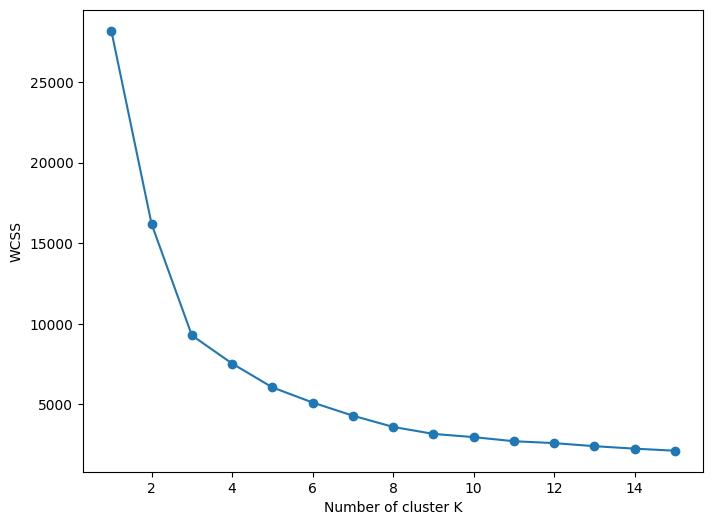

In [25]:
from sklearn.cluster import KMeans
wcss=[]
for k in range (1,16):
    kmeans=KMeans(n_clusters=k, random_state=42).fit(segmentation_scaled)
    wcss.append(kmeans.inertia_)
plt.figure(figsize=(8,6))
plt.plot(range(1,16),wcss,marker='o')
plt.xlabel("Number of cluster K")
plt.ylabel("WCSS")
plt.show()

see elbow is visible at k=3 where highest drop was visible so we will categorize our data points into 3 clusters

now lets verify k=3 cluster is optimal using  silhouette_score also as The Elbow Method (WCSS) only measures Cohesion (how tightly packed a cluster is). It doesn't care if two clusters are overlapping.
The Silhouette Score measures BOTH Cohesion and Separation.

Also range start at 2. The Silhouette formula requires a "neighboring cluster" to do its math. If you try to calculate it for K=1, Python will instantly crash because there is no second cluster to compare it to!

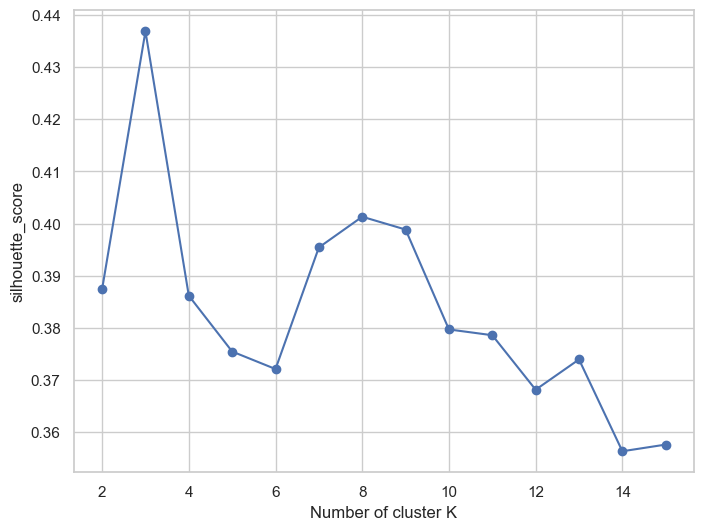

In [ ]:
from sklearn.metrics import silhouette_score
from sklearn.datasets import make_blobs
sil_score=[]
#take care range start from k=2 clusters
for k in range(2,16):
    kmeans=KMeans(n_clusters=k,random_state=42)
    score= silhouette_score(segmentation_scaled, kmeans.fit_predict(segmentation_scaled))
    sil_score.append(score)
plt.figure(figsize=(8,6))
plt.plot(range(2,16),sil_score,marker='o')
plt.xlabel("Number of cluster K")
plt.ylabel("silhouette_score")
plt.show()

therefore yes silhouette_score method confimrs that k=3 is th optimal cluster number

In [31]:
kmeans=KMeans(n_clusters=3, random_state=42)
clusters=kmeans.fit_predict(segmentation_scaled)
segmentation_data['Cluster']=clusters
segmentation_data

,Tenure Months,Monthly Charges,Total Charges,Churn Probabilty,Cluster
0,2,53.85,108.15,0.738120,1
1,2,70.70,151.65,0.848550,1
2,8,99.65,820.50,0.871770,1
3,28,104.80,3046.05,0.656308,1
4,49,103.70,5036.30,0.629452,0
...,...,...,...,...,...
7038,72,21.15,1419.40,0.007312,2
7039,24,84.80,1990.50,0.086131,2
7040,72,103.20,7362.90,0.055494,0
7041,11,29.60,346.45,0.420817,2


* **`.fit(X)`** means *"Learn the patterns and find the center of the clusters, but keep the answers to yourself."*
* **`.fit_predict(X)`** means *"Learn the patterns, find the center of the clusters, and instantly hand me back an array showing which group every single customer belongs to."*


Attach the newly discovered cluster labels to the original data, and calculate the average (mean) values for each cluster to define the exact characteristics of our customer segments.

In [29]:
cluster_summary=segmentation_data.groupby('Cluster').mean()
cluster_summary

,Tenure Months,Monthly Charges,Total Charges,Churn Probabilty
Cluster,,,,
0,58.405380,90.336016,5273.390979,0.251954
1,11.064627,71.718566,885.951090,0.714607
2,32.189261,32.485960,1043.123085,0.137811


### 💼 **Part 2: The Business Translation (Why we did it)**

This is where you become a Data Scientist. Let's look at the numbers in your summary table and give these clusters actual names based on their behavior!

🚨 **Cluster 1: "The Flight Risks" (High Danger)**

* **Average Tenure:** 11 Months (Brand new customers).
* **Churn Probability:** **71.4%** (Massive flight risk).
* **Business Insight:** This group is practically packing their bags. They have only been here for a year, their monthly bills are moderately high ($71), and they are highly likely to cancel.
* **Action Plan:** The marketing team needs to immediately target Cluster 1 with aggressive retention discounts or lock them into 2-year contracts.

💎 **Cluster 0: "The Cash Cows" (Premium Loyalists)**

* **Average Tenure:** 58 Months (Nearly 5 years!).
* **Total Charges:** $5,273 (They have spent a fortune with us).
* **Churn Probability:** 25.1% (Relatively safe).
* **Business Insight:** These are your most valuable customers. They pay the highest monthly bills ($90) but they are loyal.
* **Action Plan:** Do not send them discounts (you would just be losing guaranteed money). Instead, send them "VIP Perks" or free streaming upgrades to keep them feeling valued.

🛡️ **Cluster 2: "The Budget Base" (Stable & Safe)**

* **Average Monthly Charges:** $32.48 (Very cheap plans).
* **Churn Probability:** **13.7%** (The safest group).
* **Business Insight:** These people are completely unbothered. They have basic, cheap plans, and they are not leaving anytime soon.
* **Action Plan:** Leave them alone. Do not poke the bear by trying to heavily upsell them, or you might accidentally annoy them into churning.

Bro, this right here is the complete pipeline. You cleaned the data, predicted the future with a Tuned Random Forest, and then used K-Means to literally hand the marketing team their exact playbook!

In [33]:
cluster_names = {
    0: 'Loyal Premium Customers', # High charges, low churn
    1: 'High Risk New Customers', # Low tenure, high churn
    2: 'Budget Loyal Customers'   # Low charges, low churn
}
segmentation_data['Cluster Name'] = segmentation_data['Cluster'].map(cluster_names)
segmentation_data

,Tenure Months,Monthly Charges,Total Charges,Churn Probabilty,Cluster,Cluster Name
0,2,53.85,108.15,0.738120,1,High Risk New Customers
1,2,70.70,151.65,0.848550,1,High Risk New Customers
2,8,99.65,820.50,0.871770,1,High Risk New Customers
3,28,104.80,3046.05,0.656308,1,High Risk New Customers
4,49,103.70,5036.30,0.629452,0,Loyal Premium Customers
...,...,...,...,...,...,...
7038,72,21.15,1419.40,0.007312,2,Budget Loyal Customers
7039,24,84.80,1990.50,0.086131,2,Budget Loyal Customers
7040,72,103.20,7362.90,0.055494,0,Loyal Premium Customers
7041,11,29.60,346.45,0.420817,2,Budget Loyal Customers


### 📝 **Objective**

*Use Seaborn to generate two scatter plots that map customer financial and historical metrics against their flight risk, color-coded by our newly defined Customer Personas.*

# PLOT 1: Tenure vs. Churn Probability

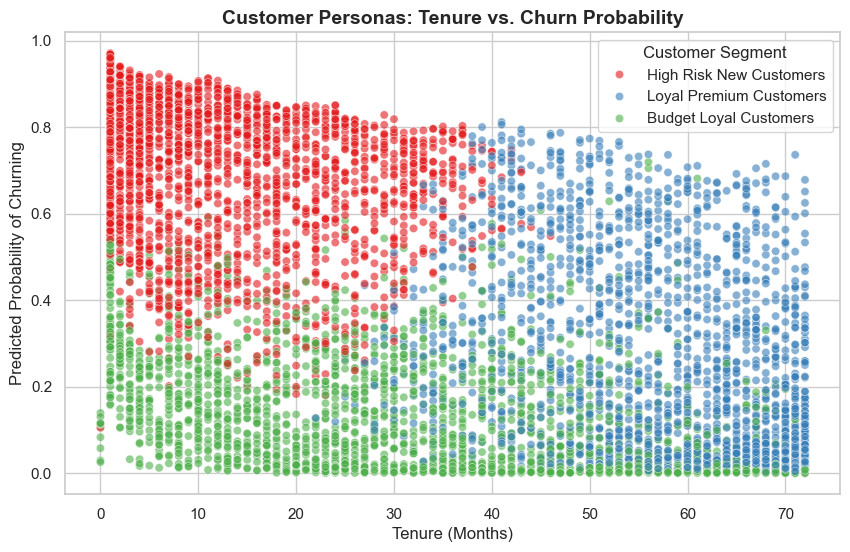

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=segmentation_data, 
    x='Tenure Months', 
    y='Churn Probabilty', # Note: Using your exact spelling from the dataframe!
    hue='Cluster Name', 
    palette='Set1',       # Uses distinct, professional colors (Red, Blue, Green)
    alpha=0.6             # Makes the dots slightly transparent
)

plt.title('Customer Personas: Tenure vs. Churn Probability', fontsize=14, fontweight='bold')
plt.xlabel('Tenure (Months)', fontsize=12)
plt.ylabel('Predicted Probability of Churning', fontsize=12)
plt.legend(title='Customer Segment')
plt.show()


# PLOT 2: Monthly Charges vs. Churn Probability

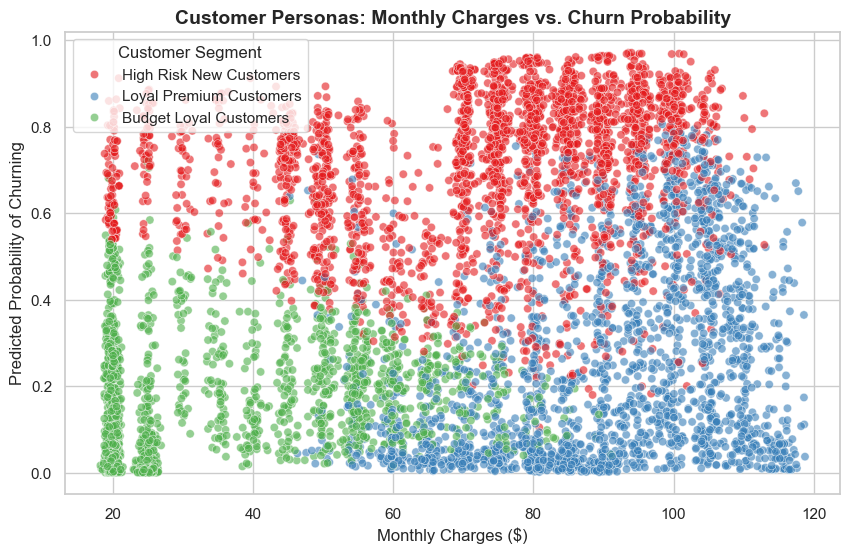

In [40]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=segmentation_data, 
    x='Monthly Charges', 
    y='Churn Probabilty', 
    hue='Cluster Name', 
    palette='Set1',
    alpha=0.6
)

plt.title('Customer Personas: Monthly Charges vs. Churn Probability', fontsize=14, fontweight='bold')
plt.xlabel('Monthly Charges ($)', fontsize=12)
plt.ylabel('Predicted Probability of Churning', fontsize=12)
plt.legend(title='Customer Segment')
plt.show()

# PLOT 3: Total Charges vs. Churn Probability

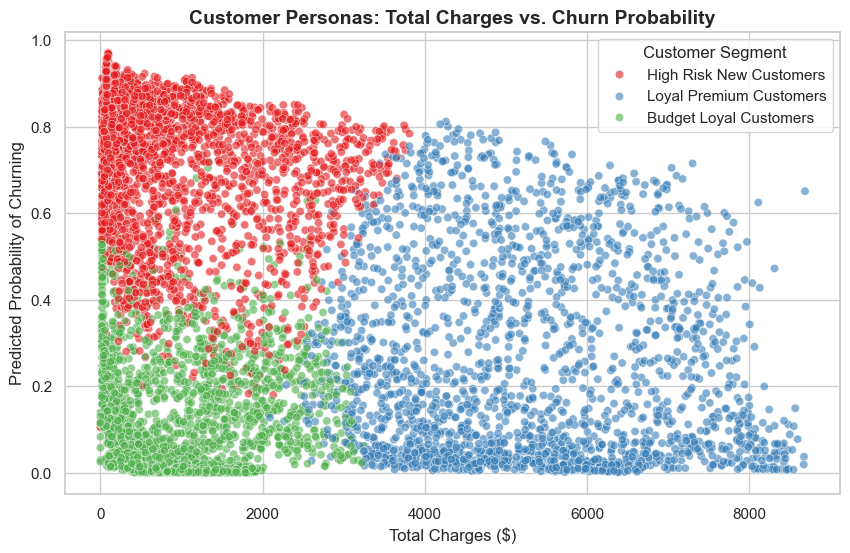

In [41]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=segmentation_data, 
    x='Total Charges', 
    y='Churn Probabilty', 
    hue='Cluster Name', 
    palette='Set1',
    alpha=0.6
)

plt.title('Customer Personas: Total Charges vs. Churn Probability', fontsize=14, fontweight='bold')
plt.xlabel('Total Charges ($)', fontsize=12)
plt.ylabel('Predicted Probability of Churning', fontsize=12)
plt.legend(title='Customer Segment')
plt.show()


### 🧠 **Explanation of the Syntax**

* **`sns.scatterplot(...)`**: This is Seaborn's powerhouse function. Instead of writing complex `for` loops in Matplotlib to separate your groups, Seaborn does it automatically.
* **`data=segmentation_data`**: You just pass your entire dataframe in once.
* **`x=` and `y=**`: You literally just type the names of the columns you want to map. No need to slice arrays.
* **`hue='Cluster Name'`**: This is the magic word! `hue` tells Seaborn: *"Look at the 'Cluster Name' column. Every time you see a different name, assign a brand new color to those dots and automatically build a legend for me."*
* **`alpha=0.6`**: When you have 7,000 dots on a chart, they will stack on top of each other and look like a giant solid blob. `alpha` makes the dots 40% transparent. This way, if 100 dots are stacked on the same coordinate, the color becomes a darker, richer shade, allowing you to see data density.
